<a href="https://colab.research.google.com/github/fralfaro/ics294-latex/blob/main/colab/certamen1_ejemplos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Certamen 1: ejemplos en R

Notebook con ejemplos sencillos para repasar las semanas 1, 2, 3 y 4 de Econometría ICS-294.

Para ejecutar código en **R** dentro de Google Colab, vaya a **Runtime > Change runtime type** y seleccione **R** como lenguaje.


## Preparación

Usaremos `dplyr` para manipular datos y `ggplot2` para gráficos. En Google Colab con kernel de R asumimos que estos paquetes están disponibles.

In [15]:
library(dplyr)
library(ggplot2)

set.seed(294)
options(scipen = 999)

tema_curso <- theme_minimal()
tema_curso


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




<theme> List of 144
 $ line                            : <ggplot2::element_line>
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ lineend      : chr "butt"
  ..@ linejoin     : chr "round"
  ..@ arrow        : logi FALSE
  ..@ arrow.fill   : chr "black"
  ..@ inherit.blank: logi TRUE
 $ rect                            : <ggplot2::element_rect>
  ..@ fill         : chr "white"
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ linejoin     : chr "round"
  ..@ inherit.blank: logi TRUE
 $ text                            : <ggplot2::element_text>
  ..@ family       : chr ""
  ..@ face         : chr "plain"
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : chr "black"
  ..@ size         : num 11
  ..@ hjust        : num 0.5
  ..@ vjust        : num 0.5
  ..@ angle        : num 0
  ..@ lineheight   : num 0.9
  ..@ margin       : <ggplot2::margin> nu

## Semana 1: datos, estadística descriptiva y correlación

Idea: antes de estimar modelos, miramos los datos. Calculamos promedios, dispersión, correlaciones y gráficos simples.

In [16]:
n <- 80

datos <- tibble(
  educ = sample(8:18, n, replace = TRUE),
  exp = sample(0:30, n, replace = TRUE),
  salario = 300 + 55 * educ + 12 * exp + rnorm(n, mean = 0, sd = 120)
)

datos %>%
  slice_head(n = 6)

educ,exp,salario
<int>,<int>,<dbl>
11,30,1291.7035
17,24,1550.9806
12,24,1316.2544
16,27,1507.5476
14,29,1466.7400
12,21,984.0317


In [17]:
datos %>%
  summarise(
    n = n(),
    salario_promedio = mean(salario),
    salario_mediano = median(salario),
    desviacion_salario = sd(salario),
    educ_promedio = mean(educ),
    exp_promedio = mean(exp),
    cor_educ_salario = cor(educ, salario)
  )

datos %>%
  group_by(educ) %>%
  summarise(
    salario_promedio = mean(salario),
    n = n(),
    .groups = "drop"
  ) %>%
  arrange(educ)

n,salario_promedio,salario_mediano,desviacion_salario,educ_promedio,exp_promedio,cor_educ_salario
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
80,1217.697,1221.306,249.5047,13.3875,14.4375,0.7726107


educ,salario_promedio,n
<int>,<dbl>,<int>
8,894.8949,4
9,918.5581,6
10,1077.8505,9
11,982.7914,9
12,1170.1557,8
13,1146.8567,2
14,1211.2317,8
15,1379.2651,5
16,1380.7650,13


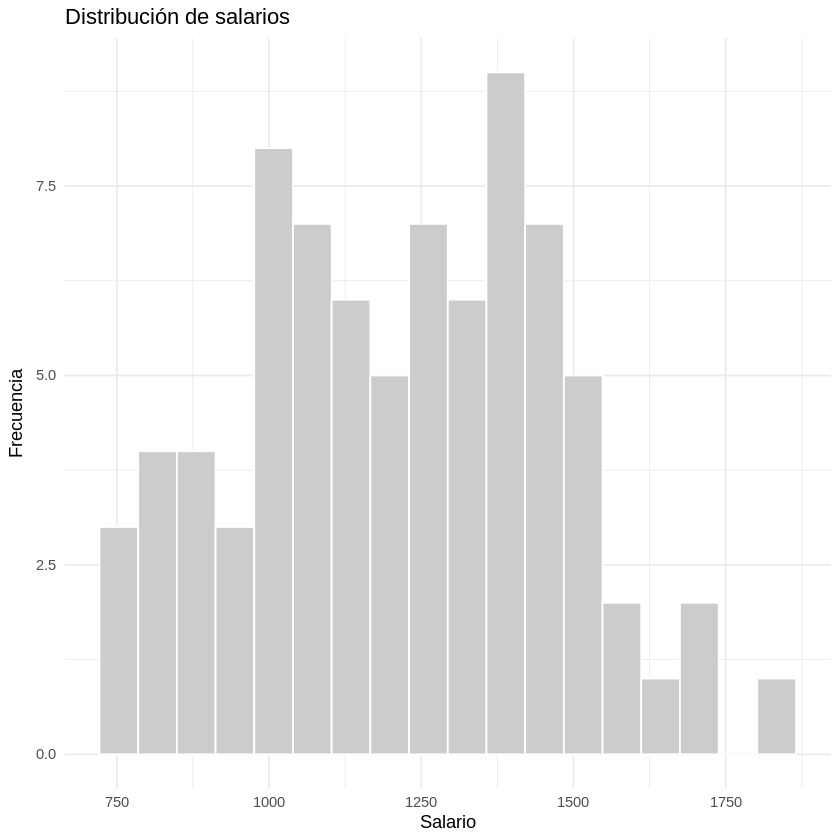

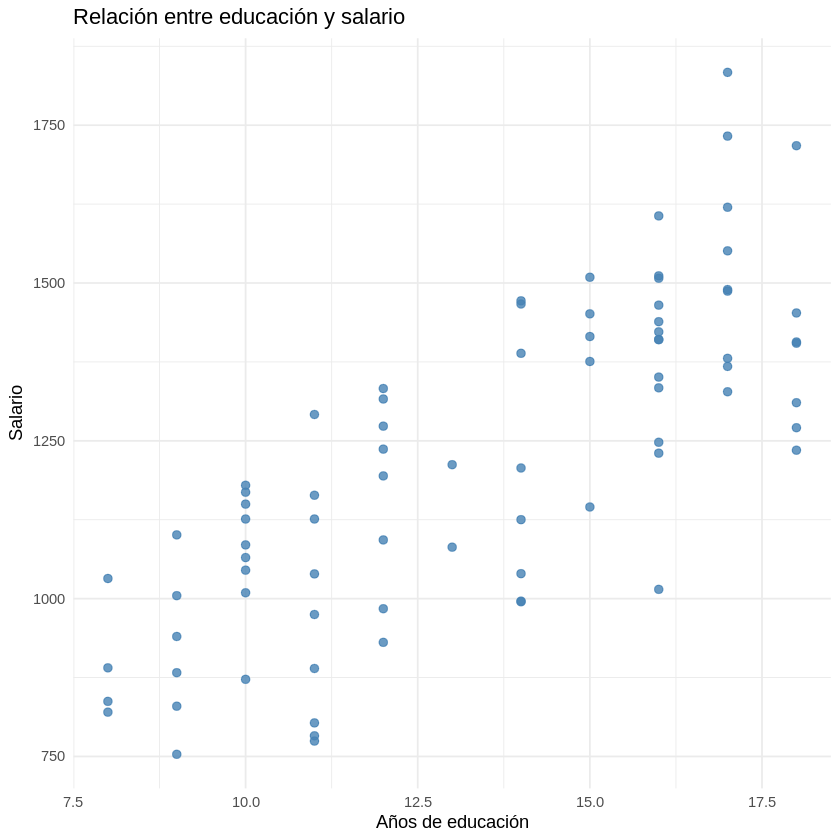

In [18]:
ggplot(datos, aes(x = salario)) +
  geom_histogram(bins = 18, fill = "gray80", color = "white") +
  labs(
    title = "Distribución de salarios",
    x = "Salario",
    y = "Frecuencia"
  ) +
  theme_minimal()

ggplot(datos, aes(x = educ, y = salario)) +
  geom_point(color = "steelblue", size = 2, alpha = 0.8) +
  labs(
    title = "Relación entre educación y salario",
    x = "Años de educación",
    y = "Salario"
  ) +
  theme_minimal()

## Semana 2: regresión lineal simple

Modelo poblacional: $y = \beta_0 + \beta_1 x + u$.

En el ejemplo estimamos cómo cambia el salario promedio cuando aumenta la educación.

In [19]:
modelo_simple <- lm(salario ~ educ, data = datos)

summary(modelo_simple)


Call:
lm(formula = salario ~ educ, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-364.07 -113.86   24.98  129.80  393.37 

Coefficients:
            Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  392.674     78.805   4.983           0.00000369 ***
educ          61.626      5.734  10.748 < 0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 159.4 on 78 degrees of freedom
Multiple R-squared:  0.5969,	Adjusted R-squared:  0.5918 
F-statistic: 115.5 on 1 and 78 DF,  p-value: < 0.00000000000000022


In [20]:
coeficientes_simple <- tibble(
  termino = names(coef(modelo_simple)),
  estimacion = as.numeric(coef(modelo_simple))
)

coeficientes_simple

coeficientes_simple %>%
  filter(termino == "educ") %>%
  mutate(
    interpretacion = paste0(
      "Un año adicional de educación se asocia con ",
      round(estimacion, 2),
      " unidades más de salario en promedio."
    )
  )

termino,estimacion
<chr>,<dbl>
(Intercept),392.67361
educ,61.62639


termino,estimacion,interpretacion
<chr>,<dbl>,<chr>
educ,61.62639,Un año adicional de educación se asocia con 61.63 unidades más de salario en promedio.


`geom_smooth()` using formula = 'y ~ x'


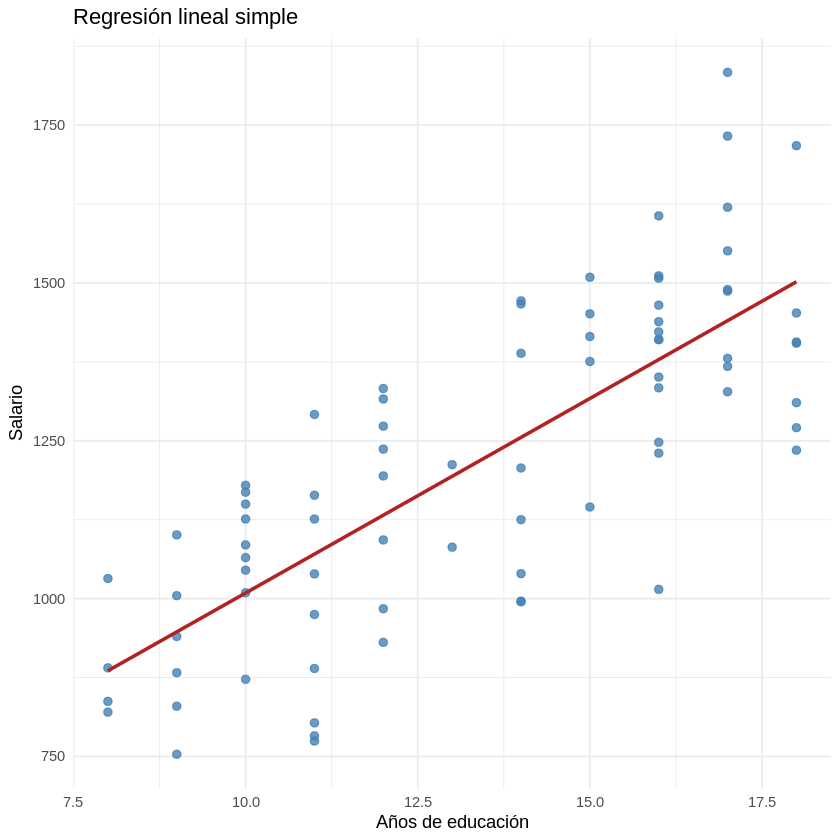

In [21]:
ggplot(datos, aes(x = educ, y = salario)) +
  geom_point(color = "steelblue", size = 2, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, color = "firebrick", linewidth = 1) +
  labs(
    title = "Regresión lineal simple",
    x = "Años de educación",
    y = "Salario"
  ) +
  theme_minimal()

In [22]:
datos_modelo_simple <- datos %>%
  mutate(
    salario_estimado = fitted(modelo_simple),
    residuo = resid(modelo_simple)
  )

datos_modelo_simple %>%
  select(salario, salario_estimado, residuo) %>%
  slice_head(n = 6)

datos_modelo_simple %>%
  summarise(suma_residuos = sum(residuo))

salario,salario_estimado,residuo
<dbl>,<dbl>,<dbl>
1291.7035,1070.564,221.1396
1550.9806,1440.322,110.6583
1316.2544,1132.190,184.0641
1507.5476,1378.696,128.8518
1466.7400,1255.443,211.2969
984.0317,1132.190,-148.1586


suma_residuos
<dbl>
-0.0000000000005710432


## Semana 3: causalidad, tratamiento y sesgo de selección

Una diferencia de promedios puede confundir efecto causal con diferencias previas entre grupos. Aquí simulamos un tratamiento y comparamos un caso aleatorio con un caso con selección.

In [23]:
n <- 200

datos_exp <- tibble(
  habilidad = rnorm(n),
  tratamiento = rbinom(n, size = 1, prob = 0.5),
  y0 = 500 + 80 * habilidad + rnorm(n, 0, 60),
  efecto_real = 100,
  y = y0 + efecto_real * tratamiento
 )

datos_exp %>%
  group_by(tratamiento) %>%
  summarise(
    promedio_y = mean(y),
    promedio_habilidad = mean(habilidad),
    n = n(),
    .groups = "drop"
  )

datos_exp %>%
  summarise(
    diferencia_promedios = mean(y[tratamiento == 1]) - mean(y[tratamiento == 0]),
    efecto_real = first(efecto_real)
  )

tratamiento,promedio_y,promedio_habilidad,n
<int>,<dbl>,<dbl>,<int>
0,489.890,0.01009588,102
1,599.358,-0.08043911,98


diferencia_promedios,efecto_real
<dbl>,<dbl>
109.468,100


In [24]:
datos_sel <- datos_exp %>%
  transmute(
    habilidad,
    tratamiento = if_else(habilidad > median(habilidad), 1, 0),
    y0,
    efecto_real,
    y = y0 + efecto_real * tratamiento
  )

datos_sel %>%
  group_by(tratamiento) %>%
  summarise(
    promedio_y = mean(y),
    promedio_y0 = mean(y0),
    promedio_habilidad = mean(habilidad),
    n = n(),
    .groups = "drop"
  )

datos_sel %>%
  summarise(
    diferencia_observada = mean(y[tratamiento == 1]) - mean(y[tratamiento == 0]),
    efecto_real = first(efecto_real),
    sesgo_seleccion = mean(y0[tratamiento == 1]) - mean(y0[tratamiento == 0])
  )

tratamiento,promedio_y,promedio_y0,promedio_habilidad,n
<dbl>,<dbl>,<dbl>,<dbl>,<int>
0,428.0332,428.0332,-0.8069166,100
1,661.0254,561.0254,0.7383841,100


diferencia_observada,efecto_real,sesgo_seleccion
<dbl>,<dbl>,<dbl>
232.9922,100,132.9922


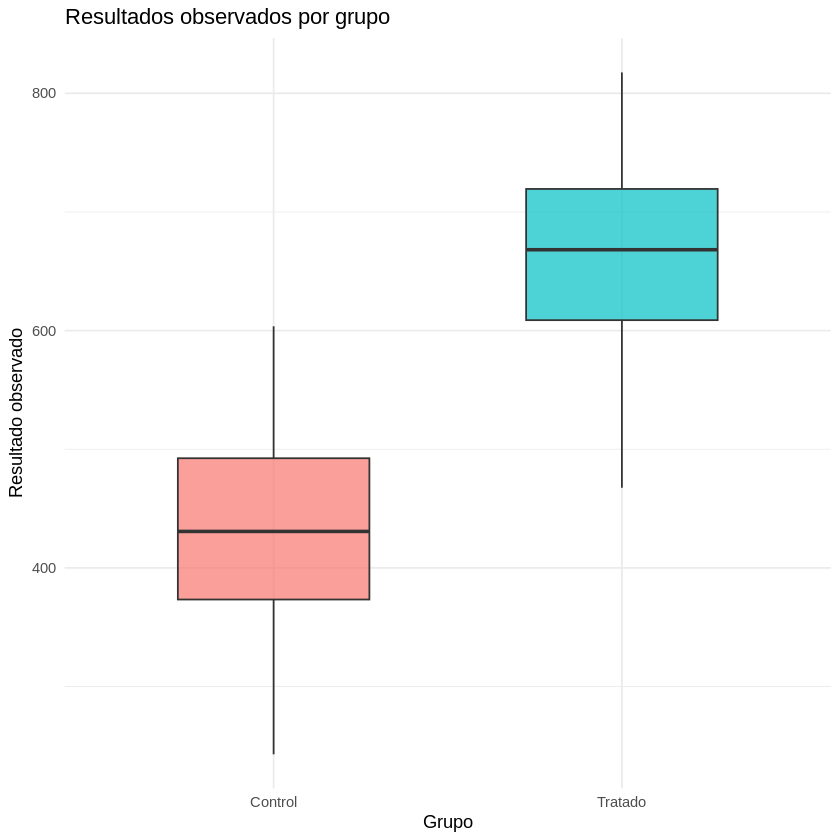

In [25]:
datos_sel %>%
  mutate(tratamiento = factor(tratamiento, labels = c("Control", "Tratado"))) %>%
  ggplot(aes(x = tratamiento, y = y, fill = tratamiento)) +
  geom_boxplot(alpha = 0.7, width = 0.55) +
  labs(
    title = "Resultados observados por grupo",
    x = "Grupo",
    y = "Resultado observado"
  ) +
  guides(fill = "none") +
  theme_minimal()

En el caso con selección, los tratados ya tenían mayor resultado potencial sin tratamiento. Por eso la diferencia observada no corresponde necesariamente al efecto causal.

## Semana 4: regresión múltiple y controles

Modelo: $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + u$.

La interpretación de $\beta_1$ es ceteris paribus: cambio promedio en $y$ cuando cambia $x_1$, manteniendo constantes las otras variables incluidas.

In [26]:
modelo_multiple <- lm(salario ~ educ + exp, data = datos)

summary(modelo_simple)
summary(modelo_multiple)


Call:
lm(formula = salario ~ educ, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-364.07 -113.86   24.98  129.80  393.37 

Coefficients:
            Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  392.674     78.805   4.983           0.00000369 ***
educ          61.626      5.734  10.748 < 0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 159.4 on 78 degrees of freedom
Multiple R-squared:  0.5969,	Adjusted R-squared:  0.5918 
F-statistic: 115.5 on 1 and 78 DF,  p-value: < 0.00000000000000022



Call:
lm(formula = salario ~ educ + exp, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-230.03  -71.59  -19.70   73.27  277.62 

Coefficients:
            Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  191.802     60.790   3.155              0.00229 ** 
educ          62.889      4.096  15.354 < 0.0000000000000002 ***
exp           12.743      1.461   8.721    0.000000000000414 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 113.8 on 77 degrees of freedom
Multiple R-squared:  0.7972,	Adjusted R-squared:  0.7919 
F-statistic: 151.4 on 2 and 77 DF,  p-value: < 0.00000000000000022


In [27]:
comparacion <- tibble(
  modelo = c("Simple: salario ~ educ", "Múltiple: salario ~ educ + exp"),
  beta_educ = c(coef(modelo_simple)[["educ"]], coef(modelo_multiple)[["educ"]]),
  r2 = c(summary(modelo_simple)$r.squared, summary(modelo_multiple)$r.squared)
)

comparacion

datos %>%
  mutate(
    salario_estimado_multiple = fitted(modelo_multiple),
    residuo_multiple = resid(modelo_multiple)
  ) %>%
  select(salario, educ, exp, salario_estimado_multiple, residuo_multiple) %>%
  slice_head(n = 6)

modelo,beta_educ,r2
<chr>,<dbl>,<dbl>
Simple: salario ~ educ,61.62639,0.5969273
Múltiple: salario ~ educ + exp,62.88854,0.7972156


salario,educ,exp,salario_estimado_multiple,residuo_multiple
<dbl>,<int>,<int>,<dbl>,<dbl>
1291.7035,11,30,1265.861,25.84304
1550.9806,17,24,1566.735,-15.75426
1316.2544,12,24,1252.292,63.96220
1507.5476,16,27,1542.075,-34.52712
1466.7400,14,29,1441.783,24.95667
984.0317,12,21,1214.064,-230.03204


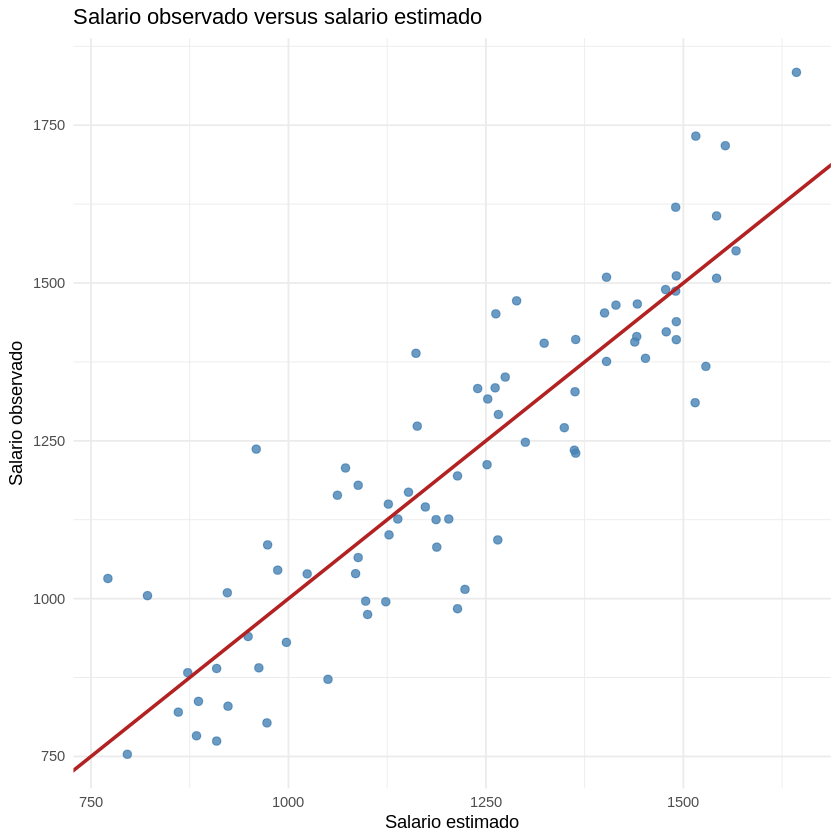

In [28]:
datos %>%
  mutate(salario_estimado_multiple = fitted(modelo_multiple)) %>%
  ggplot(aes(x = salario_estimado_multiple, y = salario)) +
  geom_point(color = "steelblue", size = 2, alpha = 0.8) +
  geom_abline(intercept = 0, slope = 1, color = "firebrick", linewidth = 1) +
  labs(
    title = "Salario observado versus salario estimado",
    x = "Salario estimado",
    y = "Salario observado"
  ) +
  theme_minimal()

In [29]:
X <- model.matrix(modelo_multiple)
y <- datos$salario

beta_matriz <- solve(t(X) %*% X) %*% t(X) %*% y

beta_matriz
coef(modelo_multiple)

(Intercept),191.80237
educ,62.88854
exp,12.74281


(Intercept)        educ         exp 
  191.80237    62.88854    12.74281

## Espacio para próximas semanas

Las siguientes secciones quedan reservadas para agregar más ejemplos cuando se necesiten.

## Semana 5: pendiente

_Agregar ejemplo aquí._

In [ ]:
# Código semana 5


## Semana 6: pendiente

_Agregar ejemplo aquí._

In [ ]:
# Código semana 6


## Semana 7: pendiente

_Agregar ejemplo aquí._

In [ ]:
# Código semana 7


## Semana 8: pendiente

_Agregar ejemplo aquí._

In [ ]:
# Código semana 8
